In [1]:
# MIT License
#
# Copyright (c) 2026 CCAI Summer School Tutorial Authors
#
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in all
# copies or substantial portions of the Software.

# Detecting Deforestation from Satellite Image Time Series
### A hands-on tutorial with Sentinel-2 data and INPE / PRODES labels — from a 1D-CNN to a Transformer and AlphaEarth foundation-model embeddings

*CCAI Virtual Summer School 2026 — AI for Forestry Monitoring*

![Amazon deforestation frontier](https://terrabrasilis.dpi.inpe.br/wp-content/uploads/2020/06/prodes-1.png)

In this tutorial you will build small deep-learning models that look at **how a
patch of land changes through time in satellite data** and decide whether it
stayed as forest or was cleared. This is a simplified, teaching-sized version of
the kind of monitoring that Brazil's National Institute for Space Research (INPE)
runs operationally over the entire Amazon.

# Table of Contents

1. [Overview & Learning Objectives](#overview)
2. [Climate Impact](#climate-impact)
3. [Background & Prerequisites](#background-and-prereqs)
4. [Software Requirements](#software-requirements)
5. [Data Description](#data-description)
6. [Data Preprocessing & Exploration](#preprocessing)
7. [Methodology: a baseline, a 1D CNN and a Transformer](#methodology)
8. [Results & Discussion](#results-and-discussion)
9. [Foundation-model features: AlphaEarth embeddings](#alphaearth)
10. [Limitations & Responsible Use](#limitations)
11. [Bonus: fetch real satellite data live](#bonus)
12. [Next Steps & References](#references)
13. [Quiz](#quiz)

**Estimated time:** ~2.5 hours · **Compute:** runs on a free Colab CPU in a few
minutes (a GPU is optional). · **Level:** basic Python + basic ML.

<a name="overview"></a>
# 1. Overview & Learning Objectives

Tropical deforestation is one of the largest sources of greenhouse-gas emissions
after fossil fuels. To slow it, governments and markets first need to **know
where and when forest is being cleared**. Satellites see the whole planet
repeatedly, but turning that flood of imagery into reliable, timely deforestation
maps is exactly the kind of problem machine learning can help with.

In this tutorial we treat each location on the ground as a **time series**: the
value of a vegetation index (NDVI) measured at that spot across one year. Forest
that is cleared shows a characteristic **drop** in this series; forest that stays
intact does not. We train a **1D Convolutional Neural Network (CNN)** and a small
**time series Transformer** to tell these trajectories apart — the same families
of methods INPE uses in its `sits` / Brazil Data Cube pipeline. At the end we
swap the hand-crafted NDVI index for learned **AlphaEarth foundation-model
embeddings** and ask an honest question: do foundation-model features beat a
simple vegetation index on this task?

### By the end of this tutorial you will be able to:

1. **Explain** why deforestation monitoring matters for the climate and who uses it.
2. **Describe** what a Satellite Image Time Series (SITS) is and why time series
   beat single-date images in cloudy tropical regions.
3. **Load and explore** a real labelled dataset built from Sentinel-2 imagery and
   INPE's PRODES deforestation polygons.
4. **Train and evaluate** a classical baseline, a 1D-CNN and a time series
   Transformer in PyTorch, and **interpret** the results with a confusion matrix
   and error analysis.
5. **Compare** hand-crafted features (NDVI) with foundation-model embeddings
   (AlphaEarth) — and recognise the **label-leakage trap** that annual embeddings
   set for you.
6. **Reason about the limitations** and the responsible-use questions that must be
   answered before a model like this is used for real decisions.
7. **Measure** the energy and carbon footprint of your own training run.

<a name="climate-impact"></a>
# 2. Climate Impact

**The carbon connection.** Forests store enormous amounts of carbon in their
biomass and soils. When a forest is cut and burned, that carbon is released to the
atmosphere as CO₂; when the forest is left standing, it keeps *absorbing* carbon.
Over 420 million hectares of forest were lost to deforestation between 1990 and
2020, more than 90% of it in the tropics (IPCC AR6, Ometto et al. 2022). Protecting
tropical forests is, in the words of the IPCC, *"a prerequisite for any global
solution to the climate crisis."*

**Why monitoring is the first step.** You cannot manage what you cannot measure.
Reliable deforestation data underpins:

- **Public policy** — Brazil's PPCDAm action plan used satellite monitoring to help
  cut Amazon deforestation ~80% between 2004 and 2012.
- **Enforcement** — daily alerts (INPE's DETER) are sent to environmental agencies
  (IBAMA) to direct field inspections.
- **Trade & finance** — the EU Deforestation Regulation (EUDR 2023/1115) bans
  commodities grown on land cleared after 31 Dec 2020; agricultural credit rules
  restrict lending on recently deforested land. Both rely on maps like PRODES.

**Who uses the output, and what is at stake.** The users are governments, agencies,
courts, banks, exporters and NGOs. A map that says "deforested here, this year"
can trigger a fine, block a loan, or stop a shipment. That is precisely why the
accuracy, transparency and *responsible use* of these models matters — a point we
return to throughout, not just at the end.

> **This tutorial builds a toy version of that monitoring signal.** It is meant to
> teach the method, not to produce operational maps.

<a name="background-and-prereqs"></a>
# 3. Background & Prerequisites

**Prerequisites.** Basic Python (loops, functions, NumPy/pandas) and a basic idea
of what supervised machine learning is (train on labelled examples, evaluate on
held-out data). No remote-sensing background is assumed — we explain the key terms
below. The neural-network section is self-contained; if it is your first CNN, focus
on the *shape of the data going in and the prediction coming out*.

### Key concept 1 — NDVI (a "greenness" number)
Satellites measure sunlight reflected by the surface in several **bands**
(wavelengths). Healthy vegetation reflects a lot of **near-infrared (NIR)** light
and absorbs **red** light. The **Normalized Difference Vegetation Index** combines
the two into a single greenness value between −1 and 1:

$$\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

Dense forest sits around 0.8–0.9; bare soil and pasture are much lower.

### Key concept 2 — Satellite Image Time Series (SITS)
A single satellite image is a snapshot. In the tropics it is often **useless on any
given day because of clouds**. Instead we stack many images over time and look at
each pixel's **trajectory**. Intact forest gives a high, roughly flat NDVI line;
a clearing event gives a **sharp, permanent drop**; agriculture gives a
**seasonal up-and-down** pattern. The *shape over time* carries the signal — that
is what our model learns to read.

### Key concept 3 — PRODES labels
Our ground-truth labels come from **PRODES**, INPE's official annual Amazon
deforestation map. Expert interpreters delineate clear-cut polygons from Sentinel-2
imagery; the product has >93% accuracy but a **1-hectare minimum mapping unit** and
an **annual** cadence. We use PRODES polygons to *label* our pixels.

### Key concept 4 — what a 1D convolution does
A 1D CNN slides small learnable filters along the time axis. Each filter responds
to a local *pattern* — for example "a high plateau followed by a drop." Stacking a
couple of these layers lets the network recognise the tell-tale temporal shapes of
deforestation without us hand-engineering them.

<a name="software-requirements"></a>
# 4. Software Requirements

Run the cell below once. On Google Colab everything except `codecarbon` is usually
pre-installed, so this is quick. **A GPU is optional** — the model is tiny and
trains in a couple of minutes on CPU. (On Colab: *Runtime → Change runtime type →
T4 GPU* if you want one.)

In [2]:
# Core dependencies (pinned for reproducibility).
!pip -q install torch numpy pandas matplotlib scikit-learn codecarbon

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| device:", DEVICE)

PyTorch 2.12.1 | device: cpu


<a name="data-description"></a>
# 5. Data Description

We use a small, pre-packaged dataset of **labelled NDVI time series** that we built
for this tutorial. Each row is one location on the ground, described by its NDVI
value at ~24 evenly spaced dates across one year, plus a label.

| Field | Meaning |
|-------|---------|
| `lon`, `lat` | location (WGS-84) |
| `label` | `forest`, `deforested`, or `old_clearing` |
| `ndvi_00 … ndvi_NN` | NDVI at each time step (start → end of the year) |

**Where it comes from (provenance).**
- **Imagery:** Sentinel-2 L2A (ESA / Copernicus), accessed via the Microsoft
  Planetary Computer, 10–20 m resolution.
- **Labels:** INPE **PRODES** *yearly deforestation* polygons, downloaded from the
  open **TerraBrasilis** service. `deforested` = inside a polygon dated to the
  target year; `old_clearing` = cleared several years earlier (now pasture-like);
  `forest` = outside all recorded clearings.
- **Region / year:** an active deforestation frontier in southern Pará, Brazil,
  for the PRODES 2022 year (Aug 2021 → Jul 2022).

**Simplifications made for teaching (be honest about these!):**
1. Only a small area and a few thousand pixels — *not* a representative sample of
   the whole Amazon.
2. Cloud gaps were filled by simple linear interpolation, hiding some real messiness.
3. Classes are roughly balanced here; real deforestation is a *rare* event (severe
   class imbalance), which makes the real problem much harder.

See `DATASHEET.md` in the repository for the full datasheet. If you cannot download
the file, the next cell falls back to a **synthetic** dataset so you can still run
everything — it is clearly flagged when that happens.

## Data Download

In [4]:
# The curated dataset ships with the tutorial repository. If you cloned the
# repo, the local file is used; otherwise (e.g. on Colab) it is downloaded.
# If both fail (e.g. offline), we generate a clearly-labelled synthetic
# dataset so the rest of the notebook still runs.
from pathlib import Path

DATA_PATH = Path("data/amazon_sits_samples.csv")
DATA_URL = (
    "https://raw.githubusercontent.com/UlisesMoyaSanchez/"
    "forestry_monitoring/main/data/amazon_sits_samples.csv"
)

def make_synthetic(n_per_class=400, n_t=24, seed=SEED):
    """Realistic-ish NDVI trajectories used only as an offline fallback."""
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 1, n_t)
    rows, labels = [], []
    def noisy(base):
        return np.clip(base + rng.normal(0, 0.03, n_t), -1, 1)
    for _ in range(n_per_class):                       # forest: high & flat
        rows.append(noisy(0.85 + 0.03*np.sin(2*np.pi*t))); labels.append("forest")
    for _ in range(n_per_class):                       # cleared this year: drop
        d = rng.integers(int(0.3*n_t), int(0.8*n_t))
        rows.append(noisy(np.where(np.arange(n_t) < d, 0.85, 0.25)))
        labels.append("deforested")
    for _ in range(n_per_class):                       # old clearing: low/seasonal
        rows.append(noisy(0.4 + 0.15*np.sin(2*np.pi*t))); labels.append("old_clearing")
    df = pd.DataFrame(rows, columns=[f"ndvi_{i:02d}" for i in range(n_t)])
    df.insert(0, "label", labels)
    return df

try:
    src = DATA_PATH if DATA_PATH.exists() else DATA_URL
    df = pd.read_csv(src)
    print(f"Loaded real dataset from {src}: {len(df)} samples")
    IS_SYNTH = False
except Exception as e:
    print(f"[!] Could not load real data ({e}).\n    Falling back to SYNTHETIC data.")
    df = make_synthetic()
    IS_SYNTH = True

NDVI_COLS = [c for c in df.columns if c.startswith("ndvi_")]
df.head()

Loaded real dataset from data/amazon_sits_samples.csv: 908 samples


,lon,lat,label,ndvi_00,ndvi_01,ndvi_02,ndvi_03,ndvi_04,ndvi_05,ndvi_06,...,ndvi_14,ndvi_15,ndvi_16,ndvi_17,ndvi_18,ndvi_19,ndvi_20,ndvi_21,ndvi_22,ndvi_23
0,-54.595477,-3.641303,deforested,0.870792,0.828480,0.867654,0.776213,0.695124,0.687961,0.680798,...,0.414334,0.337451,0.378471,0.419491,0.460511,0.501531,0.505763,0.509994,0.547848,0.552053
1,-54.571395,-3.615745,deforested,0.844116,0.838710,0.848954,0.760890,0.782955,0.635117,0.487280,...,0.350414,0.330483,0.394602,0.408693,0.422785,0.455401,0.480453,0.505506,0.509689,0.506840
2,-54.558029,-3.536081,deforested,0.867034,0.873003,0.878971,0.793343,0.437234,0.317441,0.197649,...,0.459565,0.533148,0.606731,0.607890,0.609049,0.610208,0.636942,0.629413,0.609195,0.568730
3,-54.651907,-3.637025,deforested,0.867872,0.843861,0.869378,0.846152,0.822926,0.735515,0.648103,...,0.445805,0.496051,0.546298,0.540630,0.534962,0.529294,0.535076,0.420537,0.399081,0.416116
4,-54.656760,-3.634666,deforested,0.889375,0.862412,0.886648,0.780126,0.839200,0.819455,0.799710,...,0.429726,0.388753,0.363892,0.339032,0.314171,0.397010,0.390404,0.383798,0.444522,0.421703


<a name="preprocessing"></a>
# 6. Data Preprocessing & Exploration

Before modelling, always *look* at the data. Let's inspect the class balance and
the average trajectory of each class — this is the intuition the model will exploit.

label
forest          500
old_clearing    292
deforested      116
Name: count, dtype: int64


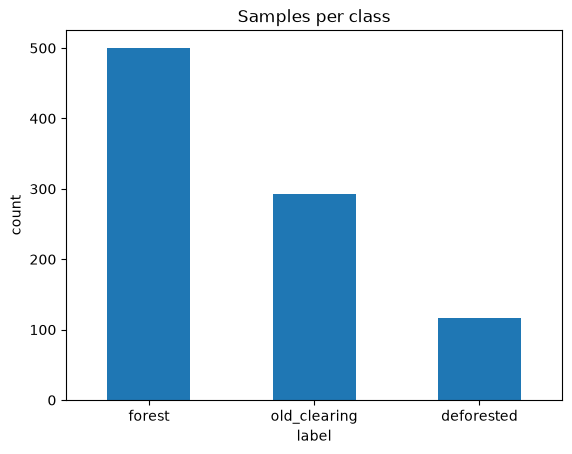

In [5]:
print(df["label"].value_counts())
df["label"].value_counts().plot.bar(rot=0, title="Samples per class");
plt.ylabel("count"); plt.show()

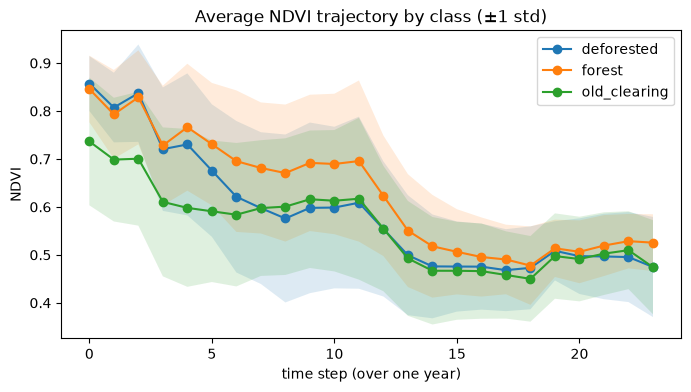

In [6]:
# Mean NDVI trajectory per class -- the "money plot".
fig, ax = plt.subplots(figsize=(8, 4))
for label, g in df.groupby("label"):
    m = g[NDVI_COLS].mean().values
    s = g[NDVI_COLS].std().values
    x = np.arange(len(NDVI_COLS))
    ax.plot(x, m, marker="o", label=label)
    ax.fill_between(x, m - s, m + s, alpha=0.15)
ax.set_xlabel("time step (over one year)"); ax.set_ylabel("NDVI")
ax.set_title("Average NDVI trajectory by class (±1 std)"); ax.legend(); plt.show()

**Read the plot.** Forest is a high, flat line. `deforested` starts high like
forest and then falls once the clearing happens — that *transition* is the signal.
`old_clearing` is already low all year. A model that only saw a single date could
easily confuse forest with a clearing that happened *after* that date; the time
series removes that ambiguity.

🖊 **Interactive checkpoint.** Plot a few *individual* deforested series below.
Notice how noisy they are and how the drop happens at different times — this is why
we need a model that finds the pattern regardless of *when* it occurs.

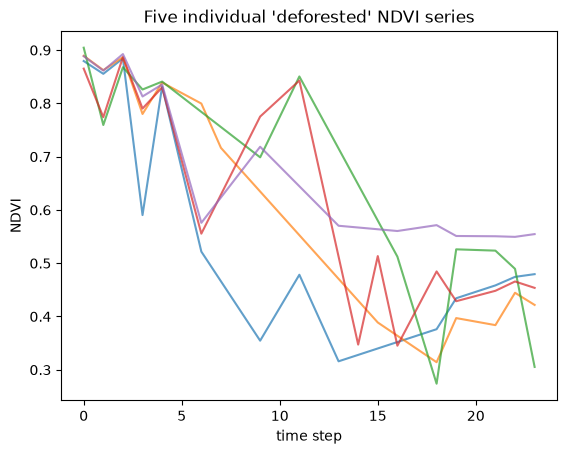

In [7]:
defo = df[df["label"] == "deforested"].sample(5, random_state=SEED)
for _, row in defo.iterrows():
    plt.plot(row[NDVI_COLS].values, alpha=0.7)
plt.title("Five individual 'deforested' NDVI series"); plt.xlabel("time step"); plt.ylabel("NDVI");
plt.show()

### Spatially-aware train/test split
A subtle but important point: nearby pixels are highly correlated (they may even come
from the same clearing). If we split randomly, near-duplicate pixels leak from train
into test and we **overestimate** accuracy. Where coordinates are available we split
by a **spatial band of longitude** so test locations are geographically separated
from training ones. (With synthetic data there is no geography, so we split randomly.)

In [8]:
from sklearn.model_selection import train_test_split

classes = sorted(df["label"].unique())
cls2idx = {c: i for i, c in enumerate(classes)}
X = df[NDVI_COLS].to_numpy("float32")
y = df["label"].map(cls2idx).to_numpy()

if (not IS_SYNTH) and {"lon", "lat"}.issubset(df.columns):
    thresh = df["lon"].quantile(0.7)          # eastern 30% -> test
    test_mask = (df["lon"] >= thresh).to_numpy()
    Xtr, Xte, ytr, yte = X[~test_mask], X[test_mask], y[~test_mask], y[test_mask]
    print("Spatial split (by longitude).")
else:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3,
                                           random_state=SEED, stratify=y)
    print("Random split.")
print(f"train={len(Xtr)}  test={len(Xte)}  classes={classes}")

Spatial split (by longitude).
train=635  test=273  classes=['deforested', 'forest', 'old_clearing']


### Where are the samples? — the split, on a map

Before training, let's *see* the geography of the split. Each dot is one sample,
coloured by its class; the shaded band on the right is the **validation zone**
(the eastern ~30% of longitudes). Because test locations are spatially separated
from training ones, a good test score cannot come from memorising neighbouring
pixels. Notice also how the classes cluster in space — deforestation happens in
patches along roads and existing clearings, not as random speckle.

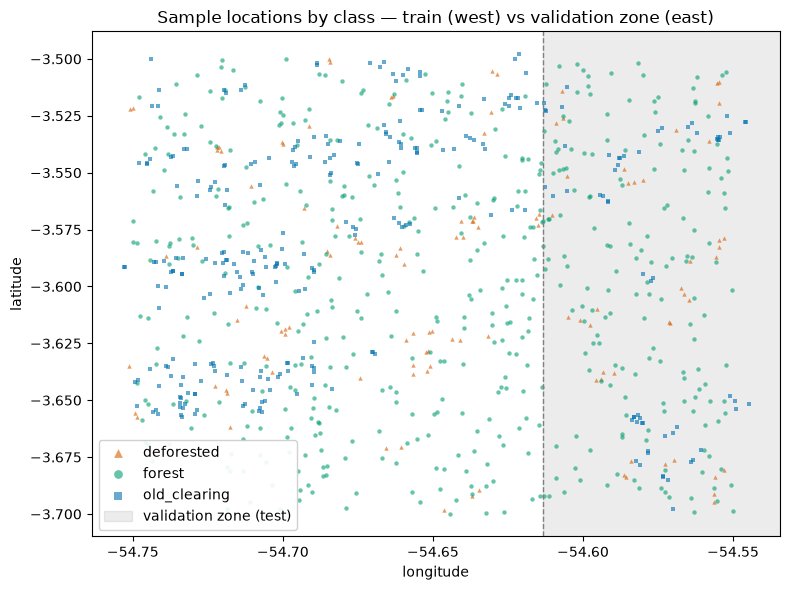

Validation zone: lon >= -54.6133  (273 test / 635 train samples)


In [9]:
if (not IS_SYNTH) and {"lon", "lat"}.issubset(df.columns):
    # Okabe-Ito colours (colour-blind safe) + distinct markers per class.
    CLASS_STYLE = {
        "forest":       {"color": "#009E73", "marker": "o"},
        "deforested":   {"color": "#D55E00", "marker": "^"},
        "old_clearing": {"color": "#0072B2", "marker": "s"},
    }
    fig, ax = plt.subplots(figsize=(8, 6))
    for label, g in df.groupby("label"):
        st = CLASS_STYLE[label]
        ax.scatter(g["lon"], g["lat"], s=10, alpha=0.6, linewidths=0,
                   color=st["color"], marker=st["marker"], label=label)
    lon_max = ax.get_xlim()[1]
    ax.axvspan(thresh, lon_max, color="grey", alpha=0.15, zorder=0,
               label="validation zone (test)")
    ax.axvline(thresh, color="grey", ls="--", lw=1)
    ax.set_xlim(right=lon_max)
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    ax.set_title("Sample locations by class — train (west) vs validation zone (east)")
    ax.legend(markerscale=2, framealpha=0.9)
    plt.tight_layout(); plt.show()
    print(f"Validation zone: lon >= {thresh:.4f}  "
          f"({test_mask.sum()} test / {(~test_mask).sum()} train samples)")
else:
    print("Synthetic data has no coordinates — nothing to map.")

<a name="methodology"></a>
# 7. Methodology

We build three models: a **classical baseline**, a **1D CNN**, and a **time
series Transformer**. Always start with a simple baseline — if a deep model
cannot beat it, the complexity is not paying off.

## 7.1 Baseline — Random Forest on the flattened series
We treat the 24 NDVI values as 24 plain features and train a Random Forest. This is
close to the classical machine-learning methods (SVM, Random Forest) that INPE used
before deep learning.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(Xtr, ytr)
rf_pred = rf.predict(Xte)
rf_acc = accuracy_score(yte, rf_pred)
rf_f1 = f1_score(yte, rf_pred, average="macro")
print(f"Random Forest  ->  accuracy={rf_acc:.3f}   macro-F1={rf_f1:.3f}")

Random Forest  ->  accuracy=0.681   macro-F1=0.588


## 7.2 The 1D Convolutional Neural Network
The CNN slides learnable filters along the **time** axis to detect temporal shapes
(plateaus, drops). Input shape is `(batch, 1 channel, 24 time steps)`; output is one
score per class. It is deliberately tiny (<10k parameters).

In [11]:
class SITSCNN(nn.Module):
    def __init__(self, n_classes, n_channels=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 16, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),      # summarise the whole series
            nn.Flatten(),
            nn.Linear(32, n_classes),
        )
    def forward(self, x):
        return self.net(x)

model = SITSCNN(len(classes)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Trainable parameters: {n_params:,}")

SITSCNN(
  (net): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (3): ReLU()
    (4): AdaptiveAvgPool1d(output_size=1)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=32, out_features=3, bias=True)
  )
)
Trainable parameters: 2,787


## 7.3 The Time Series Transformer

Transformers are the architecture behind today's large language models — and the
same idea applies to a satellite time series. Instead of sliding a fixed-width
filter along time (the CNN), **self-attention** lets *every* time step look at
*every other* time step and decide which ones matter: "was there a high plateau
early in the year, and a low tail at the end?" is exactly the kind of long-range
comparison attention is good at.

Two things to understand before the code:

- **Attention is order-blind.** Shuffling the time steps would not change the
  output, because attention treats its input as a *set*. Time order obviously
  matters for us, so we add a **positional encoding** — here the simplest kind:
  a *learned* vector per time step, added to the input (one extra `nn.Parameter`;
  the classic alternative is fixed sinusoids, see Vaswani et al. 2017).
- **We keep it tiny.** We have only ~630 training samples. A transformer this
  small (`d_model=32`, 1 layer, 2 heads, dropout 0.2) is still more flexible than
  our CNN, so watch the training curves for **overfitting** — that comparison is
  part of the lesson.

One design detail with a payoff later: the class takes input of shape
`(batch, T, C)` — any number of time steps `T`, any number of features `C` per
step. Nothing in it is hard-wired to "24 NDVI values", and in Section 9 we will
feed it a completely different kind of data without changing a line.

In [ ]:
class SITSTransformer(nn.Module):
    """Tiny transformer encoder for satellite time series.

    Input is (batch, T, C): T time steps with C features each. Nothing below is
    specific to NDVI -- the same class works for the NDVI series (T=24, C=1)
    and, later in this tutorial, for AlphaEarth embeddings (T=5 years, C=64).
    """
    def __init__(self, n_classes, in_dim=1, seq_len=24,
                 d_model=32, n_heads=2, n_layers=1, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, d_model)
        # Learned positional embedding: one trainable vector per time step.
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))
        layer = nn.TransformerEncoderLayer(
            d_model, n_heads, dim_feedforward=2 * d_model,
            dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.head = nn.Linear(d_model, n_classes)

    def forward(self, x):                                  # x: (B, T, C)
        h = self.input_proj(x) + self.pos_embed[:, :x.size(1)]
        h = self.encoder(h)                                # (B, T, d_model)
        return self.head(h.mean(dim=1))                    # average over time

tr_ndvi = SITSTransformer(len(classes), in_dim=1, seq_len=len(NDVI_COLS)).to(DEVICE)
n_params_tr = sum(p.numel() for p in tr_ndvi.parameters())
print(tr_ndvi)
print(f"Trainable parameters: {n_params_tr:,}  (CNN: {n_params:,})")

We now have **two networks** to train, so we first wrap the training loop in a
reusable `train_model()` function — same optimiser, loss and epochs for both, so
the comparison is fair. Training is wrapped in a **CodeCarbon** tracker to
measure its energy use and CO₂ emissions — a best practice for reporting the
footprint of AI work.

One shape subtlety: the CNN expects `(batch, channels, time)` while the
transformer expects `(batch, time, features)` — hence the two different
`unsqueeze` calls below.

In [ ]:
from codecarbon import EmissionsTracker

def train_model(model, Xtr_t, ytr_t, Xte_t, yte_t, epochs=400, lr=3e-3, name="model"):
    """Full-batch training loop shared by every PyTorch model in this tutorial."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    history = {"train_loss": [], "test_acc": []}
    tracker = EmissionsTracker(save_to_file=False, logging_logger=None, log_level="error")
    tracker.start()
    for epoch in range(epochs):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(Xtr_t), ytr_t)
        loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            acc = (model(Xte_t).argmax(1) == yte_t).float().mean().item()
        history["train_loss"].append(loss.item()); history["test_acc"].append(acc)
        if (epoch + 1) % 50 == 0:
            print(f"[{name}] epoch {epoch+1:3d}  loss={loss.item():.3f}  test_acc={acc:.3f}")
    emissions = tracker.stop()
    print(f"[{name}] training emitted ~{emissions*1e3:.3f} g CO2e\n")
    return history, emissions

# CNN input: (N, 1 channel, T) -- transformer input: (N, T, 1 feature).
Xtr_t = torch.tensor(Xtr).unsqueeze(1).to(DEVICE)
Xte_t = torch.tensor(Xte).unsqueeze(1).to(DEVICE)
Xtr_seq = torch.tensor(Xtr).unsqueeze(-1).to(DEVICE)
Xte_seq = torch.tensor(Xte).unsqueeze(-1).to(DEVICE)
ytr_t = torch.tensor(ytr, dtype=torch.long).to(DEVICE)
yte_t = torch.tensor(yte, dtype=torch.long).to(DEVICE)

history, _ = train_model(model, Xtr_t, ytr_t, Xte_t, yte_t, name="1D-CNN")
hist_tr, _ = train_model(tr_ndvi, Xtr_seq, ytr_t, Xte_seq, yte_t, name="transformer")

print("Tiny numbers -- but imagine training this over all of Brazil, repeatedly.")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="1D-CNN")
ax[0].plot(hist_tr["train_loss"], label="Transformer")
ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["test_acc"], label="1D-CNN")
ax[1].plot(hist_tr["test_acc"], label="Transformer")
ax[1].axhline(1/len(classes), ls="--", c="grey", label="chance")
ax[1].set_title("Test accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.show()

🖊 **Interactive checkpoint — experiment!** Re-run the cells above after changing
one thing at a time and note the effect on test accuracy:
- **`kernel_size`** (e.g. 3 vs 7): how wide a temporal pattern each CNN filter sees.
- **number of filters** (16/32 → 8/16 or 32/64): CNN capacity.
- **epochs**: pass `epochs=800` to `train_model` — watch the loss keep falling
  while test accuracy stalls or drops. That gap is **overfitting**.
- **Transformer capacity**: `d_model` (32 → 64) or `n_layers` (1 → 2). More
  capacity on ~630 training samples usually means *more* overfitting, not more skill.
- **Transformer `dropout`**: set it to 0 and compare the two curves above — the
  train/test gap should widen visibly.

<a name="results-and-discussion"></a>
# 8. Results & Discussion

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, recall_score)

def score_row(y_true, y_pred):
    """The three numbers we care about for every model."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro-F1": f1_score(y_true, y_pred, average="macro"),
        "deforested recall": recall_score(
            y_true, y_pred, labels=list(range(len(classes))),
            average=None, zero_division=0)[cls2idx["deforested"]],
    }

model.eval(); tr_ndvi.eval()
with torch.no_grad():
    cnn_pred = model(Xte_t).argmax(1).cpu().numpy()
    tr_pred = tr_ndvi(Xte_seq).argmax(1).cpu().numpy()

results = {
    "Random Forest": score_row(yte, rf_pred),
    "1D-CNN": score_row(yte, cnn_pred),
    "Transformer (NDVI)": score_row(yte, tr_pred),
}
print("=== Model comparison (test set) ===")
display(pd.DataFrame(results).T.round(3))

print(classification_report(yte, cnn_pred, target_names=classes))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in [(axes[0], cnn_pred, "1D-CNN"),
                        (axes[1], tr_pred, "Transformer (NDVI)")]:
    ConfusionMatrixDisplay(
        confusion_matrix(yte, pred, labels=list(range(len(classes)))),
        display_labels=classes).plot(cmap="Greens", ax=ax, colorbar=False)
    ax.set_title(f"{title} confusion matrix")
plt.tight_layout(); plt.show()

**Interpreting the confusion matrix.** Look at the *off-diagonal* cells — those are
the mistakes. Which classes get confused? Typically `deforested` vs `old_clearing`
(both end up low) or a late-year clearing mistaken for forest. Precision and recall
matter differently here: a **false "deforested"** (low precision) could wrongly
flag an innocent landholder, while a **missed clearing** (low recall) lets
deforestation go undetected. There is no single "accuracy" that captures both.

🖊 **Interactive checkpoint — error analysis.** The cell below plots the series the
model got *most confidently wrong*. Can you see why it was fooled (a cloud residue,
a seasonal dip, an ambiguous drift)?

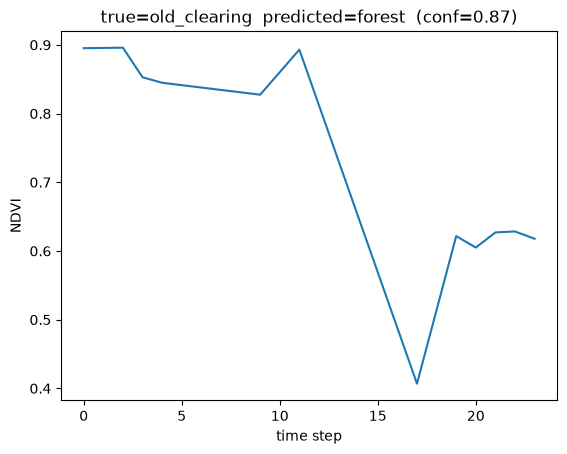

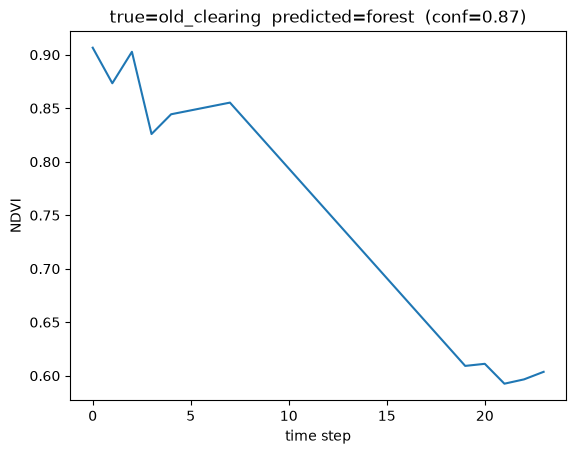

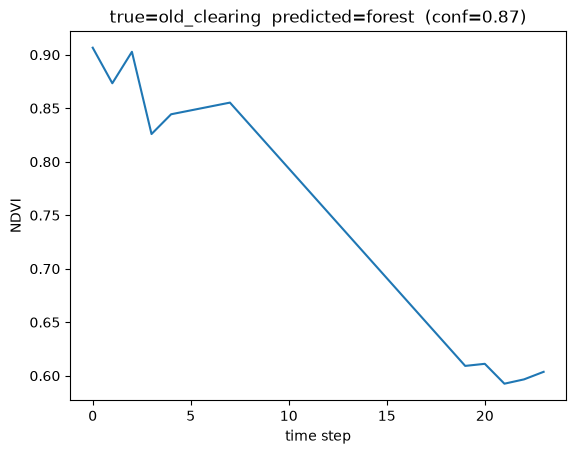

In [15]:
with torch.no_grad():
    probs = torch.softmax(model(Xte_t), dim=1).cpu().numpy()
wrong = np.where(cnn_pred != yte)[0]
if len(wrong):
    conf = probs[wrong, cnn_pred[wrong]]
    for i in wrong[np.argsort(-conf)][:3]:
        plt.plot(Xte[i])
        plt.title(f"true={classes[yte[i]]}  predicted={classes[cnn_pred[i]]}"
                  f"  (conf={probs[i, cnn_pred[i]]:.2f})")
        plt.xlabel("time step"); plt.ylabel("NDVI"); plt.show()
else:
    print("No misclassifications on the test set for this run.")

<a name="alphaearth"></a>
# 9. Foundation-model features: AlphaEarth embeddings

So far every model has looked at one hand-crafted feature: NDVI. **AlphaEarth
Foundations** (Google DeepMind, 2025) takes the opposite approach: a large
foundation model ingests a year of raw multi-sensor satellite data (optical,
radar, lidar, climate, …) and distils each 10 m pixel of the planet into a
**64-dimensional embedding vector** summarising everything it saw that year.
The embeddings for every year since 2017 are published as the *Satellite
Embedding* dataset in Google Earth Engine.

That changes the shape of our problem. NDVI gave us 24 steps *within* one year;
AlphaEarth gives **one 64-vector per year**, so a location's story becomes a
*multi-year* sequence — 2018 → 2022 is a series of 5 steps with 64 features
each. Our `SITSTransformer` takes `(batch, T, C)` for any `T` and `C`, so the
**same class** can consume this completely different input without changing a
line of model code.

**The honest question:** do learned foundation-model features beat a simple
hand-crafted index on our task? Let's find out.

*Extraction note: Earth Engine needs a Google account, so — exactly like the
NDVI data — the embeddings for our 908 sample points were pre-extracted with a
creator-side script and shipped as a small CSV. You do not need any account;
see the end of this section for how it was made.*

In [ ]:
# Like the NDVI data: local file -> download -> clearly-flagged synthetic fallback.
AE_PATH = Path("data/amazon_alphaearth_samples.csv")
AE_URL = (
    "https://raw.githubusercontent.com/UlisesMoyaSanchez/"
    "forestry_monitoring/main/data/amazon_alphaearth_samples.csv"
)
AE_ALL_YEARS = list(range(2018, 2025))   # what the CSV contains
N_DIMS = 64

def make_synthetic_alphaearth(labels, years=AE_ALL_YEARS, n_dims=N_DIMS, seed=SEED):
    """Synthetic embeddings, row-aligned with `labels` (offline fallback only).

    Each class is a Gaussian cluster in 64-d; the 'deforested' cluster sits on
    the forest centre until 2021 and jumps to the old-clearing centre from 2022
    onward -- mimicking how a real clearing moves through embedding space."""
    rng = np.random.default_rng(seed)
    centre = {"forest": rng.normal(0, 0.3, n_dims),
              "old_clearing": rng.normal(0, 0.3, n_dims)}
    frames = [pd.DataFrame({"label": labels})]
    for year in years:
        cols = [f"emb_{year}_{b:02d}" for b in range(n_dims)]
        mat = np.empty((len(labels), n_dims), dtype=np.float32)
        for i, lab in enumerate(labels):
            key = ("old_clearing"
                   if lab == "old_clearing" or (lab == "deforested" and year >= 2022)
                   else "forest")
            mat[i] = centre[key] + rng.normal(0, 0.15, n_dims)
        frames.append(pd.DataFrame(mat, columns=cols))
    return pd.concat(frames, axis=1)

try:
    src = AE_PATH if AE_PATH.exists() else AE_URL
    ae_df = pd.read_csv(src)
    print(f"Loaded AlphaEarth embeddings from {src}: {len(ae_df)} rows")
    # The CSV was built row-for-row from the same sample points as `df`.
    assert len(ae_df) == len(df), "embedding CSV is not aligned with the NDVI data"
    if {"lon", "lat"}.issubset(df.columns):
        assert np.allclose(ae_df[["lon", "lat"]], df[["lon", "lat"]], atol=1e-6), \
            "embedding CSV coordinates do not match the NDVI CSV"
    IS_SYNTH_AE = False
except Exception as e:
    print(f"[!] Could not load embeddings ({e}).\n    Falling back to SYNTHETIC embeddings.")
    ae_df = make_synthetic_alphaearth(df["label"].tolist())
    IS_SYNTH_AE = True

In [ ]:
# Default: years up to and including the PRODES target year (2022).
# Why not 2023-2024? See the leakage discussion below -- then come back and try!
EMB_YEARS = [y for y in AE_ALL_YEARS if y <= 2022]

emb_cols = [f"emb_{y}_{b:02d}" for y in EMB_YEARS for b in range(N_DIMS)]
valid = ae_df[emb_cols].notna().all(axis=1).to_numpy()   # drop masked pixels
X_emb = (ae_df.loc[valid, emb_cols].to_numpy("float32")
         .reshape(valid.sum(), len(EMB_YEARS), N_DIMS))
y_emb = y[valid]                                          # labels are row-aligned

if (not IS_SYNTH) and (not IS_SYNTH_AE):
    m = test_mask[valid]              # the SAME spatial split as the NDVI models
    Xtr_e, Xte_e, ytr_e, yte_e = X_emb[~m], X_emb[m], y_emb[~m], y_emb[m]
    print("Reusing the spatial split (by longitude).")
else:
    Xtr_e, Xte_e, ytr_e, yte_e = train_test_split(
        X_emb, y_emb, test_size=0.3, random_state=SEED, stratify=y_emb)
    print("Random split.")
print(f"X_emb: {X_emb.shape}  (samples, years, embedding dims)   "
      f"train={len(Xtr_e)}  test={len(Xte_e)}")

In [ ]:
# Same class as before -- only the input shape changes.
tr_ae = SITSTransformer(len(classes), in_dim=N_DIMS, seq_len=len(EMB_YEARS)).to(DEVICE)
print(f"Same SITSTransformer, new input: (batch, {len(EMB_YEARS)}, {N_DIMS}) "
      f"instead of (batch, {len(NDVI_COLS)}, 1)")

Xtr_e_t = torch.tensor(Xtr_e).to(DEVICE)
Xte_e_t = torch.tensor(Xte_e).to(DEVICE)
ytr_e_t = torch.tensor(ytr_e, dtype=torch.long).to(DEVICE)
yte_e_t = torch.tensor(yte_e, dtype=torch.long).to(DEVICE)

hist_ae, _ = train_model(tr_ae, Xtr_e_t, ytr_e_t, Xte_e_t, yte_e_t,
                         name="transformer-AE")

In [ ]:
tr_ae.eval()
with torch.no_grad():
    ae_pred = tr_ae(Xte_e_t).argmax(1).cpu().numpy()

results["Transformer (AlphaEarth)"] = score_row(yte_e, ae_pred)
print("=== Final model comparison (test set) ===")
display(pd.DataFrame(results).T.round(3))

ConfusionMatrixDisplay(
    confusion_matrix(yte_e, ae_pred, labels=list(range(len(classes)))),
    display_labels=classes).plot(cmap="Greens")
plt.title("Transformer (AlphaEarth) confusion matrix"); plt.show()

### ⚠️ The label-leakage trap

Why did we stop at 2022? The PRODES label says "cleared during the 2022 season".
An **annual** embedding for 2023 or 2024 summarises a year in which the land was
*already bare* — feeding those years to the model is like asking "was this pixel
deforested in 2022?" while showing it a photo from 2024. Scores shoot up, but the
model has learned nothing about *detecting* a clearing: it is simply reading the
answer off the input. In a real early-warning system those "future" features
would not exist at prediction time.

(To be fully honest: even the 2022 embedding partly post-dates the clearing.
That is the detection year itself, so it is fair game for this task — the same
way our NDVI series includes the drop — but the distinction matters.)

🖊 **Interactive checkpoint — watch leakage happen.** In the split cell above,
set `EMB_YEARS = AE_ALL_YEARS` (i.e. include 2023–2024) and re-run this section.
`deforested recall` should jump. Now explain in one sentence why that higher
number would be a *lie* for an operational monitoring system.

### How the embedding CSV was fetched (creator-side)

Only the tutorial *author* needed Google Earth Engine access. The script
[`data_prep/build_alphaearth.py`](https://github.com/UlisesMoyaSanchez/forestry_monitoring/blob/main/data_prep/build_alphaearth.py)
reads the same 908 sample points as the NDVI CSV and, for each year, samples the
64 embedding bands (`A00…A63`) of the
[Satellite Embedding dataset](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL)
at 10 m resolution. In essence (do not run this — it needs an Earth Engine account):

```python
import ee
ee.Initialize(project="my-project")                    # author-only, one time
pts = ee.FeatureCollection([...])                      # our 908 (lon, lat) points
img = (ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1_ANNUAL")
         .filterDate("2022-01-01", "2023-01-01").mosaic())
samples = img.sampleRegions(collection=pts, scale=10)  # 64 values per point
```

The result is `data/amazon_alphaearth_samples.csv` (908 rows × 7 years × 64
dimensions) plus `data/alphaearth_metadata.json` recording the provenance —
the same transparency we practise for the NDVI dataset.

<a name="limitations"></a>
# 10. Limitations & Responsible Use

This model is a **teaching demonstration**, not a monitoring system. Before anything
like it is used for a real decision, these questions must be answered:

- **It does not generalise.** It was trained on a couple of Sentinel-2 tiles in one
  region and year. Other biomes, sensors, seasons and cloud regimes would break it.
- **The labels are imperfect and coarse.** PRODES has a 1-ha minimum mapping unit and
  an annual cadence, so small or slow clearings and **forest degradation** (selective
  logging, fire) are largely invisible to both the labels *and* this model.
- **Real deforestation is rare.** We balanced the classes for teaching. In reality the
  positive class is a tiny fraction of pixels, and naïve accuracy becomes meaningless.
- **Foundation-model features are opaque.** An NDVI drop can be explained to a judge
  or a landholder; dimension 37 of a learned embedding cannot. If a model's output
  triggers enforcement, the inability to explain *why* is itself a limitation — and
  we cannot audit what went into training the foundation model either.
- **Temporal leakage is easy and silent.** As Section 9 showed, feeding the model
  annual features from *after* the event inflates every metric while destroying the
  system's real-world value. Production systems need strict "features available at
  prediction time only" discipline.
- **Who is affected if it is wrong?** A false "deforested" flag could wrongly deny
  someone credit or trigger an inspection under the EUDR; a missed clearing lets illegal
  deforestation continue. Errors have real consequences for people and forests.
- **What real use would require.** Independent validation against high-resolution
  imagery, expert review of alerts, transparency about accuracy, and clear governance
  about who acts on the output and how appeals work — exactly the safeguards INPE builds
  around PRODES/DETER.

🖊 **Reflection.** Would you base an *enforcement action* on this model's output alone?
If not, what additional evidence or process would you require first? Write two or three
sentences.

<a name="bonus"></a>
# 11. Bonus (optional): fetch real satellite data live

*This section is optional and needs internet access; it may be slow. Skip it if you
are short on time.* It shows how the curated dataset was actually built: querying a
**STAC** catalogue for real Sentinel-2 scenes and extracting an NDVI time series for a
point you choose. No account is required (Microsoft Planetary Computer).

In [16]:
# Optional extra dependencies for the live-data demo.
!pip -q install pystac-client planetary-computer odc-stac

Found 35 Sentinel-2 scenes.


/home/umoya/mambaforge/envs/forestry-ccai/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


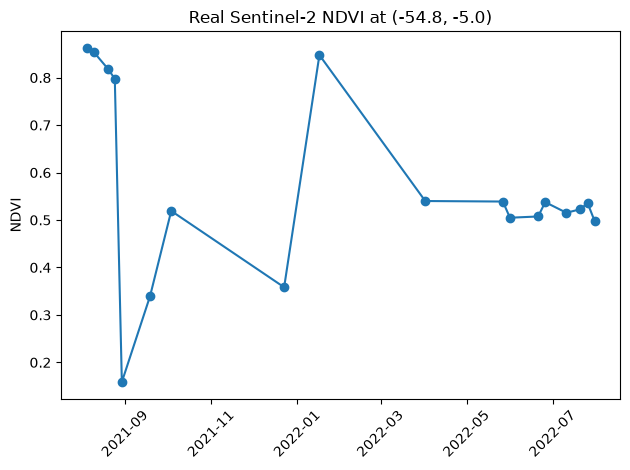

In [17]:
import planetary_computer as pc
import pystac_client
from odc.stac import stac_load

# A point in the southern Para deforestation frontier. Change it and re-run!
LON, LAT = -54.80, -5.00
buf = 0.02  # ~2 km box
bbox = (LON - buf, LAT - buf, LON + buf, LAT + buf)

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1", modifier=pc.sign_inplace)
items = list(catalog.search(collections=["sentinel-2-l2a"], bbox=bbox,
                            datetime="2021-08-01/2022-07-31",
                            query={"eo:cloud_cover": {"lt": 60}}).items())
print(f"Found {len(items)} Sentinel-2 scenes.")

# resolution is in CRS units: EPSG:4326 uses degrees, and 0.00018 deg ~ 20 m.
cube = stac_load(items, bands=["red", "nir", "SCL"], bbox=bbox,
                 resolution=0.00018, crs="EPSG:4326", groupby="solar_day", chunks={})
scl = cube["SCL"]
valid = scl.isin([4, 5, 6, 7])
ndvi = ((cube["nir"] - cube["red"]) / (cube["nir"] + cube["red"])).where(valid)
series = ndvi.sel(longitude=LON, latitude=LAT, method="nearest").compute()
series = series.dropna("time")

plt.plot(series["time"], series.values, marker="o")
plt.title(f"Real Sentinel-2 NDVI at ({LON}, {LAT})"); plt.ylabel("NDVI"); plt.xticks(rotation=45);
plt.tight_layout(); plt.show()

<a name="references"></a>
# 12. Next Steps & References

**Where to go next**
- Add more spectral bands (SWIR, NBR) as extra input *channels* — degradation and fire
  show up in bands NDVI misses. (The transformer already accepts `C > 1` unchanged.)
- Handle real class imbalance (weighted loss, focal loss, better sampling).
- Move from per-pixel to **image** models (U-Net segmentation), which is how INPE's
  newest DETER experiments work.
- Try attention-based SITS models from the literature (Garnot & Landrieu's
  lightweight temporal attention) or use AlphaEarth embeddings with simple
  classifiers — they were designed to make small models work.
- Explore INPE's production tooling: the `sits` R package on the Brazil Data Cube.

**References**
- Almeida et al. (2022), *Methodology for Forest Monitoring used in PRODES and DETER.*
- Maurano, Adami & Almeida (2019); Parente et al. (2021) — PRODES accuracy.
- Simões et al. (2021), *Satellite Image Time Series Analysis for Big EO Data.*
- Picoli et al. (2018), *Big EO data cubes for land use and cover in Brazil.*
- Ometto et al. (2022), IPCC AR6 WGII Cross-Chapter Paper 7 (Tropical Forests).
- Vaswani et al. (2017), *Attention Is All You Need* — the transformer architecture.
- Sainte Fare Garnot & Landrieu (2020), *Lightweight Temporal Self-Attention for
  Classifying Satellite Image Time Series.*
- Brown, Kazmierski, Pasquarella et al. (2025), *AlphaEarth Foundations: An embedding
  field model for accurate and efficient global mapping from sparse label data.*
- Satellite Embedding dataset: https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL
- TerraBrasilis: https://terrabrasilis.dpi.inpe.br · Brazil Data Cube: http://brazildatacube.org
- Microsoft Planetary Computer: https://planetarycomputer.microsoft.com
- CodeCarbon: https://codecarbon.io

*Data & scientific framing adapted from Amaral (INPE, 2025), "AI-for-Forestry in the
Amazonian region."*

<a name="quiz"></a>
# 13. Quiz

Test your understanding (answers in `QUIZ.md`).

**Q1.** Why do we classify a *time series* of images rather than a single-date image
for tropical deforestation?
&nbsp;&nbsp;a) Time series are smaller files.
&nbsp;&nbsp;b) Persistent clouds make any single date unreliable, and a clearing is only
recognisable as a *drop over time*.
&nbsp;&nbsp;c) Single images cannot compute NDVI.
&nbsp;&nbsp;d) Time series remove the need for labels.

**Q2.** In the EUDR context, what is the main real-world risk of a **false-positive**
deforestation prediction? *(True/False: "It is harmless because a human checks first.")*

**Q3.** What does *spatially-aware* splitting protect against?
&nbsp;&nbsp;a) Overfitting to the optimiser · b) GPU memory errors ·
c) **Leakage from spatial autocorrelation inflating test accuracy** · d) Cloud contamination.

**Q4.** What does a 1D convolution in this model operate over?
&nbsp;&nbsp;a) The spatial x–y plane · b) **The time axis of the NDVI series** ·
c) The colour channels of an RGB image · d) The list of class labels.

**Q5.** Why does the transformer need a *positional encoding* when the CNN does not?
&nbsp;&nbsp;a) To normalise the NDVI values.
&nbsp;&nbsp;b) Self-attention treats its input as an unordered set — without position
information, shuffling the time steps would give the same output.
&nbsp;&nbsp;c) Transformers cannot handle inputs longer than 12 steps.
&nbsp;&nbsp;d) It reduces the number of parameters.

**Q6.** Adding the 2023–2024 AlphaEarth embeddings noticeably improves "deforested"
recall for the 2022 labels. Why is this **not** good news for a monitoring system?
&nbsp;&nbsp;a) The extra years make training slower.
&nbsp;&nbsp;b) Embeddings from after the clearing *contain the answer* (label leakage) —
those features would not exist when a real system had to make the call.
&nbsp;&nbsp;c) Recall is not a meaningful metric.
&nbsp;&nbsp;d) The 2023–2024 embeddings are lower resolution.